In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
consolidated = pd.read_csv(
    '/content/drive/MyDrive/IT5006_Olist_Project/smartcommerce_consolidated.csv'
)
print(consolidated.shape)
print(consolidated.columns.tolist())

(112650, 25)
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'product_category_name_english', 'product_weight_g', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'customer_state', 'customer_city', 'seller_state', 'order_date', 'year_month', 'year', 'month', 'day_of_week', 'delivery_days', 'is_on_time', 'item_revenue']


In [ ]:
consolidated.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name_english,product_weight_g,customer_id,...,customer_city,seller_state,order_date,year_month,year,month,day_of_week,delivery_days,is_on_time,item_revenue
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,650.0,3ce436f183e68e07877b285a838db11a,...,campos dos goytacazes,SP,2017-09-13,2017-09,2017,9,Wednesday,7.0,True,72.19
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,30000.0,f6dd3ec061db4e3987629fe6b26e5cce,...,santa fe do sul,SP,2017-04-26,2017-04,2017,4,Wednesday,16.0,True,259.83
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,furniture_decor,3050.0,6489ae5e4333f3693df5ad4372dab6d3,...,para de minas,MG,2018-01-14,2018-01,2018,1,Sunday,7.0,True,216.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumery,200.0,d4eb9395c8c0431ee92fce09860c5a06,...,atibaia,SP,2018-08-08,2018-08,2018,8,Wednesday,6.0,True,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,garden_tools,3750.0,58dbd0b2d70206bf40e62cd34e84d795,...,varzea paulista,PR,2017-02-04,2017-02,2017,2,Saturday,25.0,True,218.04


In [ ]:
print("Rows:", len(consolidated))
print("Unique orders:", consolidated['order_id'].nunique())

Rows: 112650
Unique orders: 98666


In [ ]:
df = pd.read_csv(
    '/content/drive/MyDrive/IT5006_Olist_Project/smartcommerce_consolidated.csv',
    parse_dates=[
        'order_purchase_timestamp',
        'order_delivered_customer_date',
        'order_estimated_delivery_date'
    ]
)

In [ ]:
print("Rows:", len(df))
print("Unique orders:", df['order_id'].nunique())

Rows: 112650
Unique orders: 98666


In [ ]:
order_level = (
    df.groupby('order_id')
      .agg(
          order_status=('order_status', 'first'),
          purchase_time=('order_purchase_timestamp', 'first'),
          delivered_time=('order_delivered_customer_date', 'first'),
          estimated_delivery=('order_estimated_delivery_date', 'first'),
          customer_state=('customer_state', 'first'),
          seller_state=('seller_state', 'first'),

          total_price=('price', 'sum'),
          total_freight=('freight_value', 'sum'),
          item_count=('order_item_id', 'count'),
          avg_product_weight=('product_weight_g', 'mean'),

          product_category=('product_category_name_english', 'first')
      )
      .reset_index()
)

Rearrange the data by order-level.

In [ ]:
print(order_level.shape)

(98666, 12)


In [ ]:
delivered = order_level[
    order_level['delivered_time'].notna()
].copy()

print(delivered.shape)

(96476, 12)


Keep the records of really delivered.

In [ ]:
delivered['is_late'] = (
    delivered['delivered_time'] >
    delivered['estimated_delivery']
).astype(int)

In [ ]:
delivered['is_late'].value_counts()

,count
is_late,
0,88649
1,7827


In [ ]:
delivered['is_late'].value_counts(normalize=True) * 100

,proportion
is_late,
0,91.887101
1,8.112899


What features are related to late delivery? Test in order:
1. Temporal
*   monthly v.s weekly
2. Geography
*   same state delivery v.s cross-state delivery
*   late rate by customer state

*   late rate by customer state
3.   Order cost or physical characteristics
*   Freight/Price/Weight
4. Product category
5. Item count


1. Temporal
*   monthly v.s weekly



In [ ]:
delivered['purchase_month'] = delivered['purchase_time'].dt.to_period('M').astype(str)
delivered['purchase_weekday'] = delivered['purchase_time'].dt.day_name()

In [ ]:
late_by_month = (
    delivered.groupby('purchase_month')
    .agg(
        late_rate=('is_late', 'mean'),
        order_count=('order_id', 'count')
    )
    .reset_index()
)

late_by_month['late_rate_pct'] = late_by_month['late_rate'] * 100

late_by_month

,purchase_month,late_rate,order_count,late_rate_pct
0,2016-09,1.000000,1,100.000000
1,2016-10,0.011111,270,1.111111
2,2016-12,0.000000,1,0.000000
3,2017-01,0.030667,750,3.066667
4,2017-02,0.032063,1653,3.206292
5,2017-03,0.055774,2546,5.577376
6,2017-04,0.078593,2303,7.859314
7,2017-05,0.036107,3545,3.610719
8,2017-06,0.038596,3135,3.859649
9,2017-07,0.034349,3872,3.434917


In [ ]:
late_by_weekday = (
    delivered.groupby('purchase_weekday')
    .agg(
        late_rate=('is_late', 'mean'),
        order_count=('order_id', 'count')
    )
)

late_by_weekday['late_rate_pct'] = late_by_weekday['late_rate'] * 100

late_by_weekday.sort_values('late_rate_pct', ascending=False)

,late_rate,order_count,late_rate_pct
purchase_weekday,,,
Monday,0.090556,15703,9.055594
Tuesday,0.084892,15502,8.489227
Friday,0.084472,13685,8.447205
Wednesday,0.078015,15074,7.801513
Saturday,0.075976,10556,7.597575
Thursday,0.075688,14322,7.568775
Sunday,0.074867,11634,7.486677


Monthly eda results worth scrutinization.

In [ ]:
late_by_month_plot = late_by_month[
    late_by_month['order_count'] >= 500
]

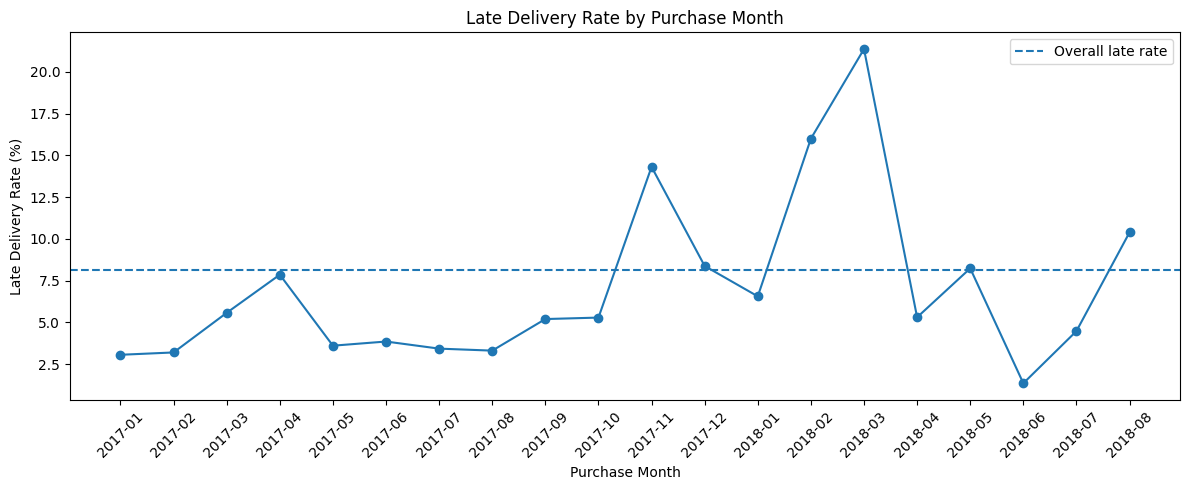

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(
    late_by_month_plot['purchase_month'],
    late_by_month_plot['late_rate_pct'],
    marker='o'
)

plt.axhline(
    delivered['is_late'].mean() * 100,
    linestyle='--',
    label='Overall late rate'
)

plt.xticks(rotation=45)
plt.xlabel('Purchase Month')
plt.ylabel('Late Delivery Rate (%)')
plt.title('Late Delivery Rate by Purchase Month')
plt.legend()
plt.tight_layout()
plt.show()

Late delivery rates show substantial temporal variation. While the overall late-delivery rate is approximately 8.1%, rates increased sharply in several periods, reaching 14.3% in November 2017, 16.0% in February 2018 and 21.4% in March 2018. This suggests that seasonality and order timing may be useful predictors of late-delivery risk.

2. Geography
*   same state delivery v.s cross-state delivery
*   late rate by customer state

*   late rate by customer state





In [ ]:
delivered['same_state'] = (
    delivered['customer_state'] == delivered['seller_state']
).astype(int)

In [ ]:
same_state_summary = (
    delivered.groupby('same_state')
    .agg(
        late_rate=('is_late', 'mean'),
        order_count=('order_id', 'count')
    )
)

same_state_summary['late_rate_pct'] = (
    same_state_summary['late_rate'] * 100
)

same_state_summary

,late_rate,order_count,late_rate_pct
same_state,,,
0,0.092662,61773,9.266184
1,0.060600,34703,6.059995


Cross-state orders showed a higher late-delivery rate (9.27%) than same-state orders (6.06%), suggesting that geographic separation between sellers and customers may contribute to delivery risk.

In [ ]:
late_by_state = (
    delivered
    .groupby('customer_state')
    .agg(
        late_rate=('is_late', 'mean'),
        orders=('order_id', 'count')
    )
    .reset_index()
)

late_by_state['late_rate'] *= 100

late_by_state = (
    late_by_state[late_by_state['orders'] >= 100]
    .sort_values('late_rate', ascending=False)
    .reset_index(drop=True)
)

late_by_state

,customer_state,late_rate,orders
0,AL,23.929471,397
1,MA,19.665272,717
2,PI,15.966387,476
3,CE,15.324472,1279
4,SE,15.223881,335
5,BA,14.035627,3256
6,RJ,13.470412,12353
7,TO,12.773723,274
8,PA,12.367865,946
9,ES,12.230576,1995


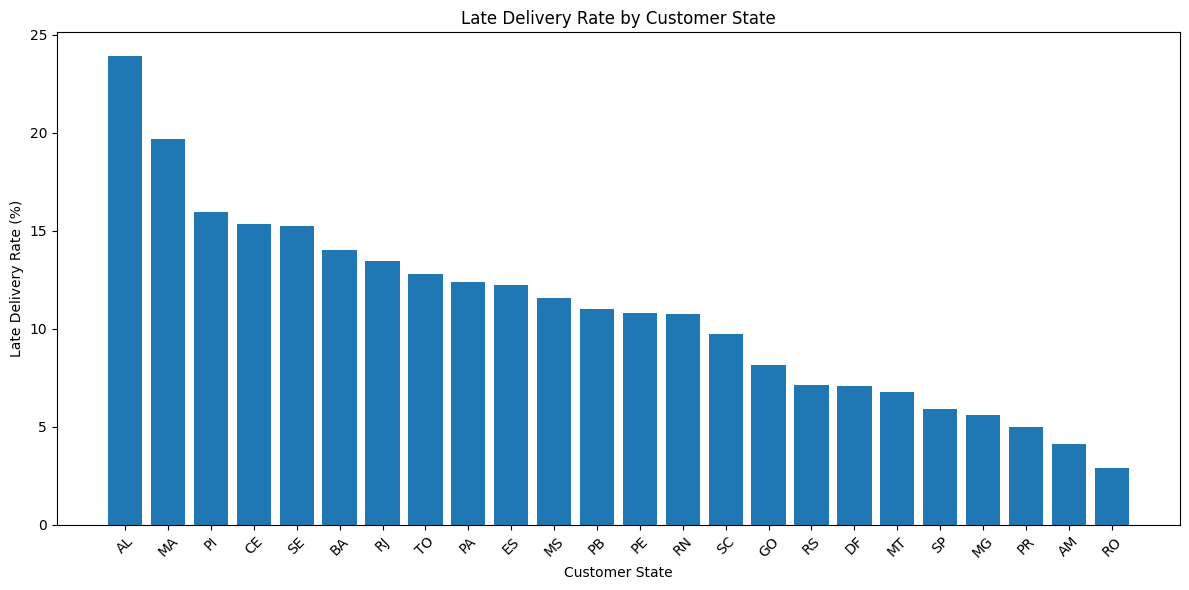

In [ ]:
plt.figure(figsize=(12, 6))

plt.bar(
    late_by_state['customer_state'],
    late_by_state['late_rate']
)

plt.title('Late Delivery Rate by Customer State')
plt.xlabel('Customer State')
plt.ylabel('Late Delivery Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

Late-delivery rates varied substantially across customer states, ranging from about 2.9% to 23.9% among states with at least 100 delivered orders, suggesting meaningful geographic differences in delivery performance.

In [ ]:
late_by_seller_state = (
    delivered
    .groupby('seller_state')
    .agg(
        late_rate=('is_late', 'mean'),
        orders=('order_id', 'count')
    )
    .reset_index()
)

late_by_seller_state['late_rate'] *= 100

late_by_seller_state = (
    late_by_seller_state[late_by_seller_state['orders'] >= 100]
    .sort_values('late_rate', ascending=False)
    .reset_index(drop=True)
)

late_by_seller_state

,seller_state,late_rate,orders
0,MA,23.195876,388
1,SP,8.772673,68417
2,RJ,8.452722,4188
3,ES,7.142857,308
4,PR,6.528470,7429
5,SC,6.054632,3551
6,DF,5.977584,803
7,BA,5.828780,549
8,MG,5.635460,7648
9,MT,4.477612,134


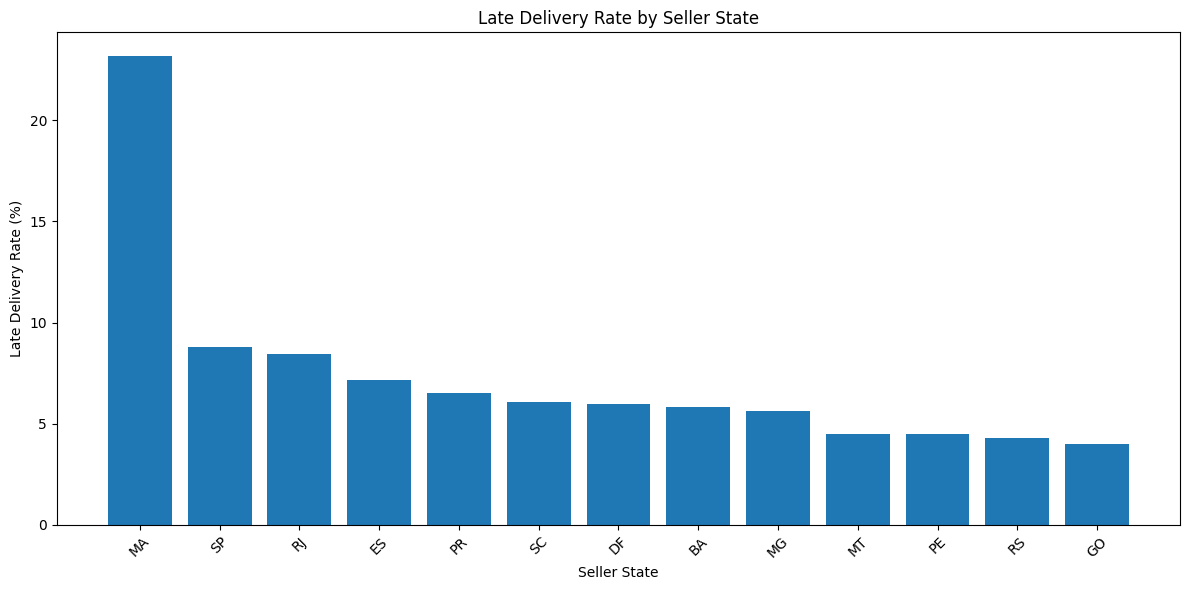

In [ ]:
plt.figure(figsize=(12, 6))

plt.bar(
    late_by_seller_state['seller_state'],
    late_by_seller_state['late_rate']
)

plt.title('Late Delivery Rate by Seller State')
plt.xlabel('Seller State')
plt.ylabel('Late Delivery Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

Late-delivery rates also varied by seller state. Maranhão (MA) had a notably high late-delivery rate of about 23.2%, while major seller states such as São Paulo (SP) and Rio de Janeiro (RJ) were around 8–9%. However, seller-state differences were less consistently pronounced than customer-state differences.



3.   Order cost or physical characteristics
*   Freight/Price/Weight





In [ ]:
delivered.groupby('is_late')[
    ['total_freight', 'total_price', 'avg_product_weight']
].agg(['mean', 'median'])

total_freight        total_price        avg_product_weight       
                 mean median        mean median               mean median
is_late                                                                  
0           22.623264  17.07  136.064080   85.5        2071.804936  688.0
1           24.622275  18.05  148.070845   89.9        2397.181763  750.0

In [ ]:
delivered['freight_bin'] = pd.qcut(
    delivered['total_freight'],
    q=5,
    duplicates='drop'
)

freight_late = (
    delivered.groupby('freight_bin', observed=True)
    .agg(
        late_rate=('is_late', 'mean'),
        orders=('order_id', 'count')
    )
    .reset_index()
)

freight_late['late_rate'] *= 100

freight_late

,freight_bin,late_rate,orders
0,"(-0.001, 12.83]",6.077946,19398
1,"(12.83, 15.64]",7.241469,19195
2,"(15.64, 18.59]",8.859192,19381
3,"(18.59, 27.38]",9.045514,19225
4,"(27.38, 1794.96]",9.347928,19277


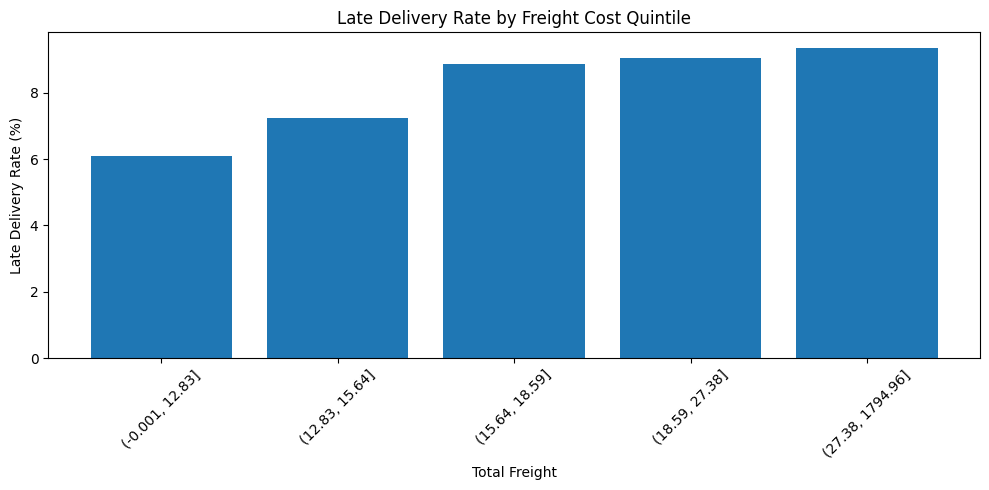

In [ ]:
plt.figure(figsize=(10, 5))

plt.bar(
    freight_late['freight_bin'].astype(str),
    freight_late['late_rate']
)

plt.title('Late Delivery Rate by Freight Cost Quintile')
plt.xlabel('Total Freight')
plt.ylabel('Late Delivery Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

Late-delivery rates increased with freight cost, rising from about 6.1% in the lowest freight quintile to 9.3% in the highest quintile. This suggests that orders with higher freight costs may face greater delivery risk.

In [ ]:
delivered['price_bin'] = pd.qcut(
    delivered['total_price'],
    q=5,
    duplicates='drop'
)

price_late = (
    delivered.groupby('price_bin', observed=True)
    .agg(
        late_rate=('is_late', 'mean'),
        orders=('order_id', 'count')
    )
    .reset_index()
)

price_late['late_rate'] *= 100

price_late

,price_bin,late_rate,orders
0,"(0.849, 39.0]",7.294130,19454
1,"(39.0, 67.9]",7.957034,19178
2,"(67.9, 106.6]",7.936013,19254
3,"(106.6, 175.0]",8.616580,19300
4,"(175.0, 13440.0]",8.766200,19290


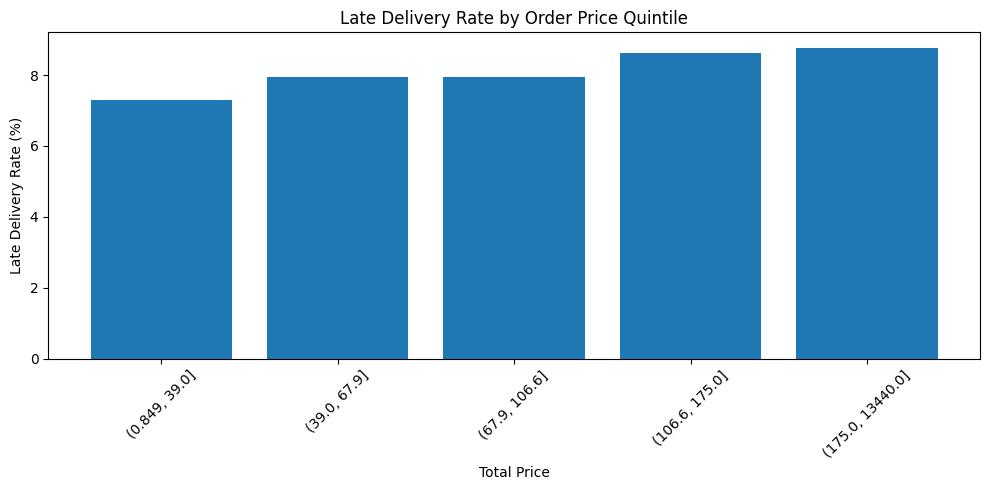

In [ ]:
plt.figure(figsize=(10, 5))

plt.bar(
    price_late['price_bin'].astype(str),
    price_late['late_rate']
)

plt.title('Late Delivery Rate by Order Price Quintile')
plt.xlabel('Total Price')
plt.ylabel('Late Delivery Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

Late-delivery rates were slightly higher for more expensive orders, increasing from about 7.3% in the lowest price quintile to 8.8% in the highest quintile. The relationship appears weaker than the pattern observed for freight cost.

In [ ]:
delivered['weight_bin'] = pd.qcut(
    delivered['avg_product_weight'],
    q=5,
    duplicates='drop'
)

weight_late = (
    delivered.groupby('weight_bin', observed=True)
    .agg(
        late_rate=('is_late', 'mean'),
        orders=('order_id', 'count')
    )
    .reset_index()
)

weight_late['late_rate'] *= 100

weight_late

,weight_bin,late_rate,orders
0,"(-0.001, 250.0]",7.346683,22323
1,"(250.0, 500.0]",8.250718,18459
2,"(500.0, 1000.0]",7.711544,17195
3,"(1000.0, 2500.0]",8.354236,19535
4,"(2500.0, 40425.0]",9.003589,18948


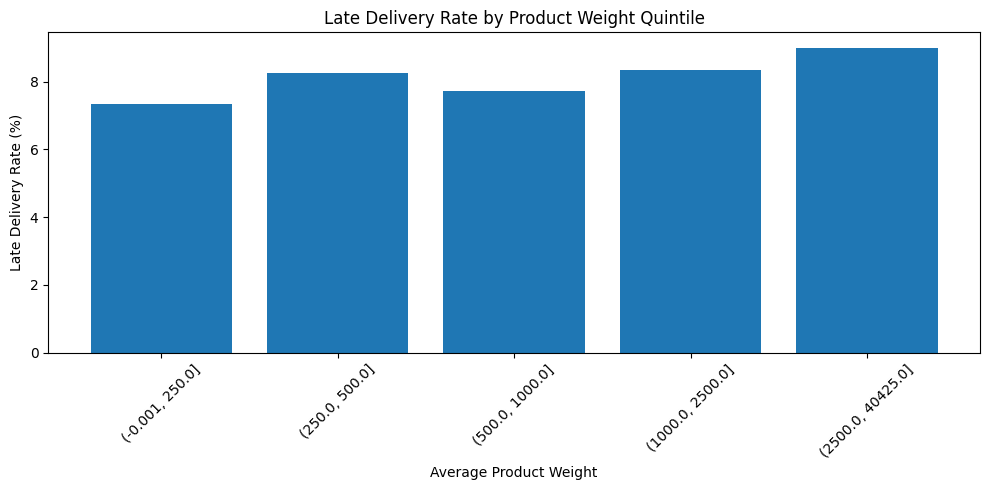

In [ ]:
plt.figure(figsize=(10, 5))

plt.bar(
    weight_late['weight_bin'].astype(str),
    weight_late['late_rate']
)

plt.title('Late Delivery Rate by Product Weight Quintile')
plt.xlabel('Average Product Weight')
plt.ylabel('Late Delivery Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

Heavier products tended to have somewhat higher late-delivery rates, with the highest-weight quintile reaching about 9.0% compared with 7.3% in the lightest group. However, the relationship was not strictly monotonic.

Freight cost showed the clearest association with late delivery, with late-delivery rates increasing steadily across freight quintiles. Higher order prices and heavier products were also associated with slightly higher late-delivery rates, although these relationships were weaker and not strictly monotonic. Overall, logistics-related cost and product characteristics may be useful predictors of delivery risk.



4.   Product category



In [ ]:
category_late = (
    delivered
    .groupby('product_category')
    .agg(
        late_rate=('is_late', 'mean'),
        orders=('order_id', 'count')
    )
    .reset_index()
)

category_late['late_rate'] *= 100

category_late = (
    category_late[category_late['orders'] >= 300]
    .sort_values('late_rate', ascending=False)
    .reset_index(drop=True)
)

category_late.head(15)

,product_category,late_rate,orders
0,audio,13.081395,344
1,home_confort,10.270270,370
2,food,10.114943,435
3,electronics,9.852413,2507
4,baby,9.337676,2763
5,office_furniture,9.229535,1246
6,construction_tools_construction,9.203297,728
7,health_beauty,9.002207,8609
8,Unknown,8.925980,1378
9,musical_instruments,8.896211,607


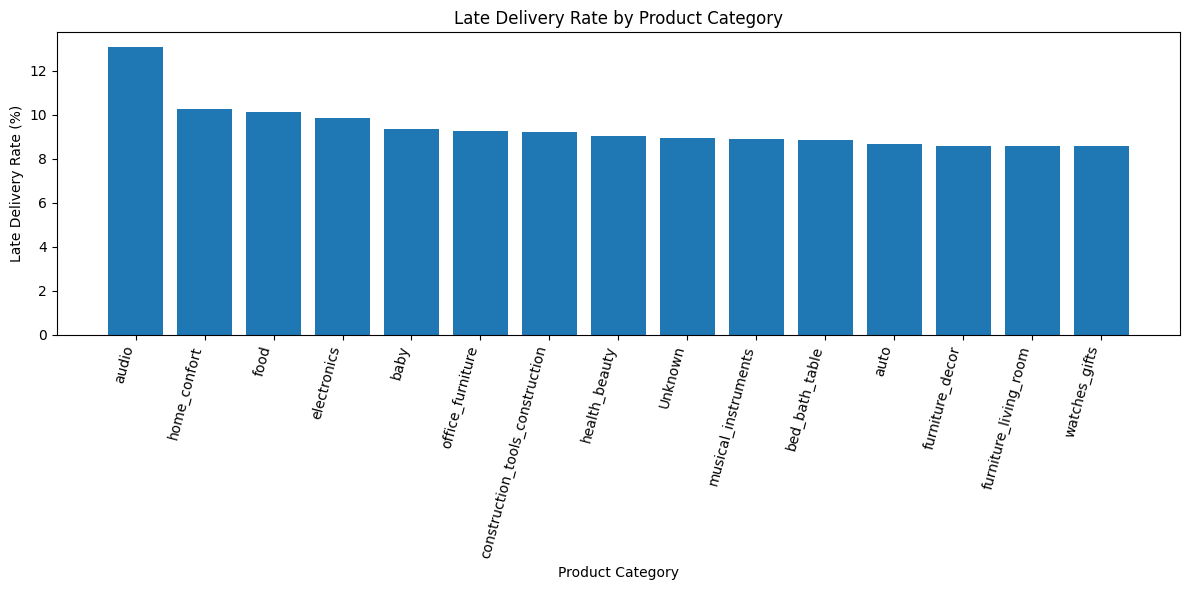

In [ ]:
top_categories = category_late.head(15)

plt.figure(figsize=(12, 6))

plt.bar(
    top_categories['product_category'],
    top_categories['late_rate']
)

plt.title('Late Delivery Rate by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Late Delivery Rate (%)')
plt.xticks(rotation=75, ha='right')
plt.tight_layout()

plt.show()

Late-delivery rates varied across product categories. Audio products had the highest late-delivery rate among categories with at least 300 orders, at about 13.1%, followed by home comfort and food products at around 10%. This suggests that product category may also contain useful information for predicting delivery risk.



5.   Item Count




In [ ]:
delivered['item_count'].value_counts().sort_index().head(15)

,count
item_count,
1,86840
2,7393
3,1306
4,495
5,193
6,191
7,22
8,8
9,3


In [ ]:
delivered['item_count_group'] = pd.cut(
    delivered['item_count'],
    bins=[0, 1, 2, 3, float('inf')],
    labels=['1', '2', '3', '4+']
)

In [ ]:
item_late = (
    delivered.groupby('item_count_group', observed=True)
    .agg(
        late_rate=('is_late', 'mean'),
        orders=('order_id', 'count')
    )
    .reset_index()
)

item_late['late_rate'] *= 100

item_late

,item_count_group,late_rate,orders
0,1,8.288807,86840
1,2,6.627891,7393
2,3,6.202144,1306
3,4+,6.189968,937


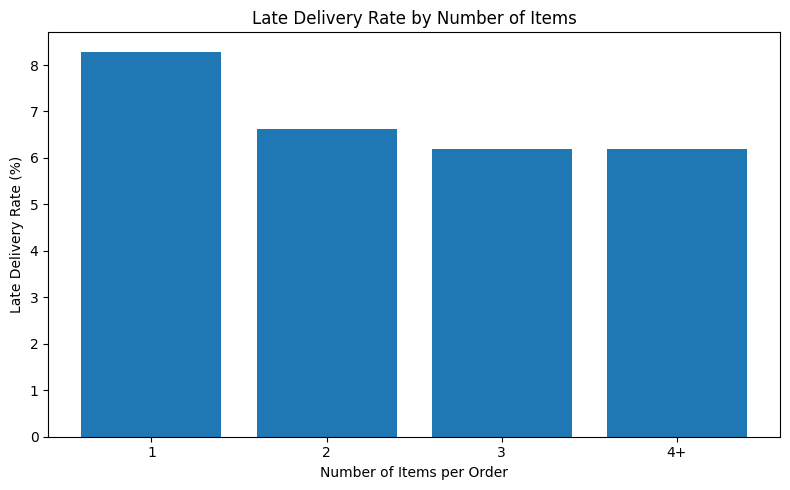

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    item_late['item_count_group'].astype(str),
    item_late['late_rate']
)

plt.title('Late Delivery Rate by Number of Items')
plt.xlabel('Number of Items per Order')
plt.ylabel('Late Delivery Rate (%)')
plt.tight_layout()

plt.show()

Orders containing a single item had the highest late-delivery rate at about 8.3%, while orders with two or more items had lower rates of around 6.2–6.6%. This suggests that item count is not positively associated with delivery risk in this dataset.


**Takeaway:**
Overall, late-delivery risk
was associated with several feature groups. Temporal patterns and geography showed clear variation, while higher freight costs had the strongest and most consistent relationship among order characteristics. Product price and weight showed weaker positive associations, product category also exhibited some variation, and item count did not show a positive relationship with late delivery. These findings suggest that temporal, geographic, logistics-cost, and product-related features are promising candidates for later classification modelling.